# Topic 3: Neural Network Processing, Backward Propagation
## How Neural Networks Learn From Their Mistakes

> **Goal:** Understand *how* a network figures out which weights to adjust, and by how much, using **backpropagation** and the **chain rule**.

---
## 1. Quick Recap: Forward Propagation

Last session we saw data flow **forward**, layer by layer:

- **Input Layer** → **Hidden Layers** → **Output Layer**
- Each neuron: `weighted sum` → `activation function`
- The final output is compared to the true answer using a **loss function**

Forward propagation answers *"what does the network predict?"*. Today's question is *"how does it learn from being wrong?"*

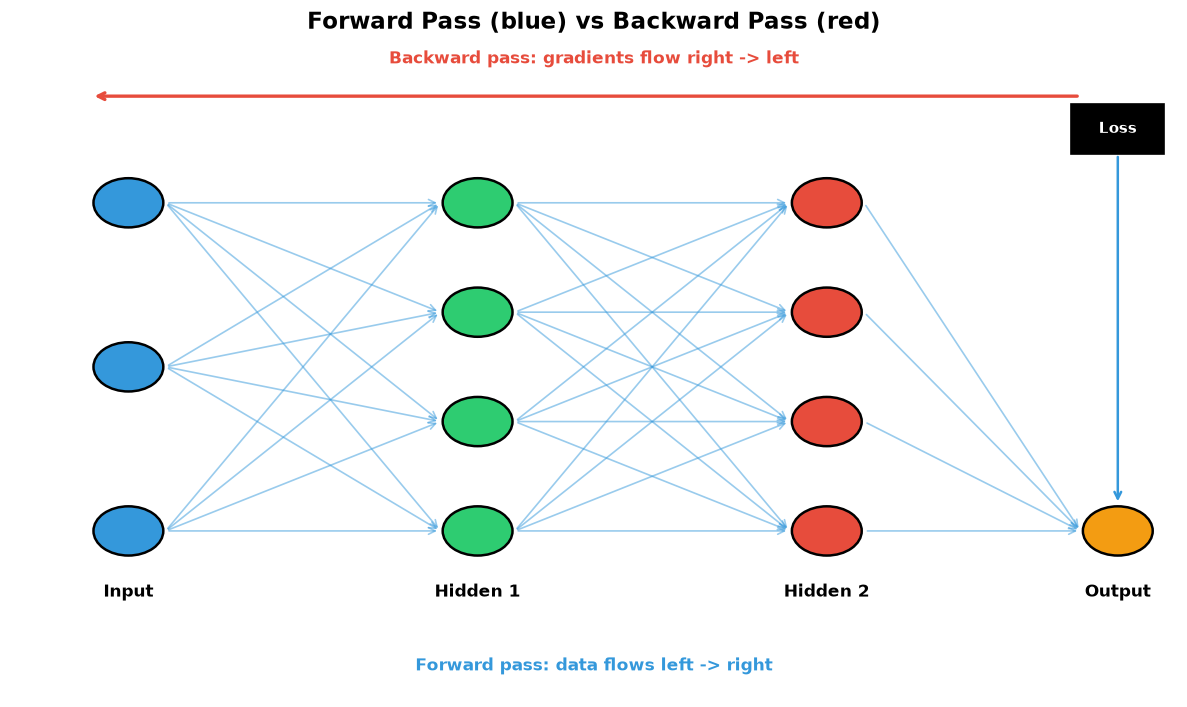

Forward pass computes the prediction and the loss.
Backward pass (backpropagation) sends the loss's gradient back through every layer,
telling each weight exactly how it should change to reduce the loss.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Let's draw the forward pass (blue, left-to-right) and the
# backward pass (red, right-to-left) on the same network diagram.
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Forward Pass (blue) vs Backward Pass (red)', fontsize=14, fontweight='bold')

layer_names = ['Input', 'Hidden 1', 'Hidden 2', 'Output']
layer_x = [1, 4, 7, 9.5]
layer_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
layer_sizes = [3, 4, 4, 1]

positions = []
for x, size in zip(layer_x, layer_sizes):
    positions.append(np.linspace(2, 6, size))

for x, name, color, size, ys in zip(layer_x, layer_names, layer_colors, layer_sizes, positions):
    for y in ys:
        circle = plt.Circle((x, y), 0.3, color=color, ec='black', linewidth=1.5, zorder=3)
        ax.add_patch(circle)
    ax.text(x, 1.2, name, ha='center', fontsize=10, fontweight='bold')

# Forward connections (thin blue arrows, left -> right)
for i in range(len(layer_x) - 1):
    x1, x2 = layer_x[i], layer_x[i + 1]
    for y1 in positions[i]:
        for y2 in positions[i + 1]:
            ax.annotate('', xy=(x2 - 0.32, y2), xytext=(x1 + 0.32, y1),
                        arrowprops=dict(arrowstyle='->', color='#3498db', alpha=0.5, linewidth=1))

# The Loss box, sitting after the output neuron
loss_x = 9.5
ax.add_patch(plt.Rectangle((loss_x - 0.4, 6.6), 0.8, 0.6, color='black', zorder=3))
ax.text(loss_x, 6.9, 'Loss', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.annotate('', xy=(loss_x, positions[-1][0] + 0.32), xytext=(loss_x, 6.6),
            arrowprops=dict(arrowstyle='->', color='#3498db', linewidth=1.5))

# Backward arrow (thick red, right -> left) showing gradients flowing back
ax.annotate('', xy=(layer_x[0] - 0.32, 7.3), xytext=(layer_x[-1] - 0.32, 7.3),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', linewidth=2))

ax.text(5, 7.7, 'Backward pass: gradients flow right -> left', color='#e74c3c',
        fontsize=10, fontweight='bold', ha='center')
ax.text(5, 0.3, 'Forward pass: data flows left -> right', color='#3498db',
        fontsize=10, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

print("Forward pass computes the prediction and the loss.")
print("Backward pass (backpropagation) sends the loss's gradient back through every layer,")
print("telling each weight exactly how it should change to reduce the loss.")

---
## 2. Why Do We Need Backpropagation?

A real network can have thousands (even millions) of weights. After a forward pass we get one number — the **loss** — telling us how wrong we were.

The hard question: **which weights caused the error, and by how much should each one change?**

We can't try every weight one at a time — that would take forever. **Backpropagation** is an algorithm that computes the exact gradient for *every* weight in a network with a single backward sweep, by reusing intermediate results and applying the **chain rule** from calculus.

In [2]:
# The chain rule, demonstrated on a tiny example
# u = 2x + 1
# y = u^2
# We want dy/dx

def f(x):
    u = 2 * x + 1
    y = u ** 2
    return y, u

x = 3.0
y, u = f(x)

# --- Analytic derivative using the chain rule ---
# dy/du = 2u        du/dx = 2
# dy/dx = dy/du * du/dx
dy_du = 2 * u
du_dx = 2
dy_dx_chain_rule = dy_du * du_dx

# --- Numerical derivative (finite differences), as a sanity check ---
epsilon = 1e-6
y_plus, _ = f(x + epsilon)
y_minus, _ = f(x - epsilon)
dy_dx_numerical = (y_plus - y_minus) / (2 * epsilon)

print(f"x = {x},  u = 2x + 1 = {u},  y = u^2 = {y}")
print(f"\nChain rule:  dy/dx = (dy/du)({dy_du}) x (du/dx)({du_dx}) = {dy_dx_chain_rule}")
print(f"Numerical:   dy/dx ~= {dy_dx_numerical:.4f}")
print(f"\nBoth methods agree: {np.isclose(dy_dx_chain_rule, dy_dx_numerical)}")
print("\nA neural network is just a much longer chain of tiny functions like this one.")
print("The chain rule lets us find how any early weight affects the FINAL loss.")

x = 3.0,  u = 2x + 1 = 7.0,  y = u^2 = 49.0

Chain rule:  dy/dx = (dy/du)(14.0) x (du/dx)(2) = 28.0
Numerical:   dy/dx ~= 28.0000

Both methods agree: True

A neural network is just a much longer chain of tiny functions like this one.
The chain rule lets us find how any early weight affects the FINAL loss.


---
## 3. Backpropagation Through a Single Neuron

Let's trace the chain rule through one neuron, step by step:

```
z = w * x + b
a = activation(z)
Loss = (a - target)^2
```

We work **backward**: first find how the loss changes with `a`, then with `z`, then with `w`, `b`, and `x`.

In [3]:
def relu(x):
    return max(0, x)

print("=" * 55)
print("BACKPROPAGATION THROUGH A SINGLE NEURON")
print("=" * 55)

# A single neuron: z = w*x + b, a = ReLU(z), Loss = (a - target)^2
x = 2.0
w = 0.6
b = 0.1
target = 3.0

print(f"\nSetup: x = {x}, w = {w}, b = {b}, target = {target}")

# ---------------- FORWARD PASS ----------------
z = w * x + b
a = relu(z)
loss = (a - target) ** 2

print("\n--- FORWARD PASS ---")
print(f"z = w*x + b = {w}*{x} + {b} = {z}")
print(f"a = ReLU(z) = {a}")
print(f"Loss = (a - target)^2 = ({a} - {target})^2 = {loss:.4f}")

# ---------------- BACKWARD PASS ----------------
print("\n--- BACKWARD PASS (Chain Rule, one step at a time) ---")

dloss_da = 2 * (a - target)
print(f"Step 1: dLoss/da = 2*(a - target) = {dloss_da:.4f}")

da_dz = 1.0 if z > 0 else 0.0
print(f"Step 2: da/dz = ReLU'(z) = {da_dz}  (z = {z} is {'positive' if z > 0 else 'non-positive'})")

dloss_dz = dloss_da * da_dz
print(f"        dLoss/dz = dLoss/da * da/dz = {dloss_da:.4f} * {da_dz} = {dloss_dz:.4f}")

dloss_dw = dloss_dz * x   # dz/dw = x
dloss_db = dloss_dz * 1.0 # dz/db = 1
dloss_dx = dloss_dz * w   # dz/dx = w (passed further back)

print(f"Step 3: dLoss/dw = dLoss/dz * dz/dw = {dloss_dz:.4f} * {x} = {dloss_dw:.4f}")
print(f"Step 4: dLoss/db = dLoss/dz * dz/db = {dloss_dz:.4f} * 1 = {dloss_db:.4f}")
print(f"Step 5: dLoss/dx = dLoss/dz * dz/dw(prev layer) = {dloss_dz:.4f} * {w} = {dloss_dx:.4f}")

# ---------------- ONE GRADIENT DESCENT STEP ----------------
learning_rate = 0.05
w_new = w - learning_rate * dloss_dw
b_new = b - learning_rate * dloss_db

print("\n--- GRADIENT DESCENT UPDATE ---")
print(f"new_w = w - lr * dLoss/dw = {w} - {learning_rate}*{dloss_dw:.4f} = {w_new:.4f}")
print(f"new_b = b - lr * dLoss/db = {b} - {learning_rate}*{dloss_db:.4f} = {b_new:.4f}")

z2 = w_new * x + b_new
a2 = relu(z2)
loss2 = (a2 - target) ** 2
print(f"\nLoss BEFORE update: {loss:.4f}")
print(f"Loss AFTER update:  {loss2:.4f}  -> the update moved us closer to the target!")

BACKPROPAGATION THROUGH A SINGLE NEURON

Setup: x = 2.0, w = 0.6, b = 0.1, target = 3.0

--- FORWARD PASS ---
z = w*x + b = 0.6*2.0 + 0.1 = 1.3
a = ReLU(z) = 1.3
Loss = (a - target)^2 = (1.3 - 3.0)^2 = 2.8900

--- BACKWARD PASS (Chain Rule, one step at a time) ---
Step 1: dLoss/da = 2*(a - target) = -3.4000
Step 2: da/dz = ReLU'(z) = 1.0  (z = 1.3 is positive)
        dLoss/dz = dLoss/da * da/dz = -3.4000 * 1.0 = -3.4000
Step 3: dLoss/dw = dLoss/dz * dz/dw = -3.4000 * 2.0 = -6.8000
Step 4: dLoss/db = dLoss/dz * dz/db = -3.4000 * 1 = -3.4000
Step 5: dLoss/dx = dLoss/dz * dz/dw(prev layer) = -3.4000 * 0.6 = -2.0400

--- GRADIENT DESCENT UPDATE ---
new_w = w - lr * dLoss/dw = 0.6 - 0.05*-6.8000 = 0.9400
new_b = b - lr * dLoss/db = 0.1 - 0.05*-3.4000 = 0.2700

Loss BEFORE update: 2.8900
Loss AFTER update:  0.7225  -> the update moved us closer to the target!


---
## 4. Derivatives of Common Activation Functions

Every time backpropagation crosses an activation function, it needs that function's **derivative** to convert `dLoss/da` into `dLoss/dz`.

| Activation | Function | Derivative |
| :--- | :--- | :--- |
| **ReLU** | `max(0, x)` | `1` if `x > 0`, else `0` |
| **Sigmoid** | `1 / (1 + e^-x)` | `sigmoid(x) * (1 - sigmoid(x))` |
| **Tanh** | `tanh(x)` | `1 - tanh(x)^2` |

Let's plot each function alongside its derivative.

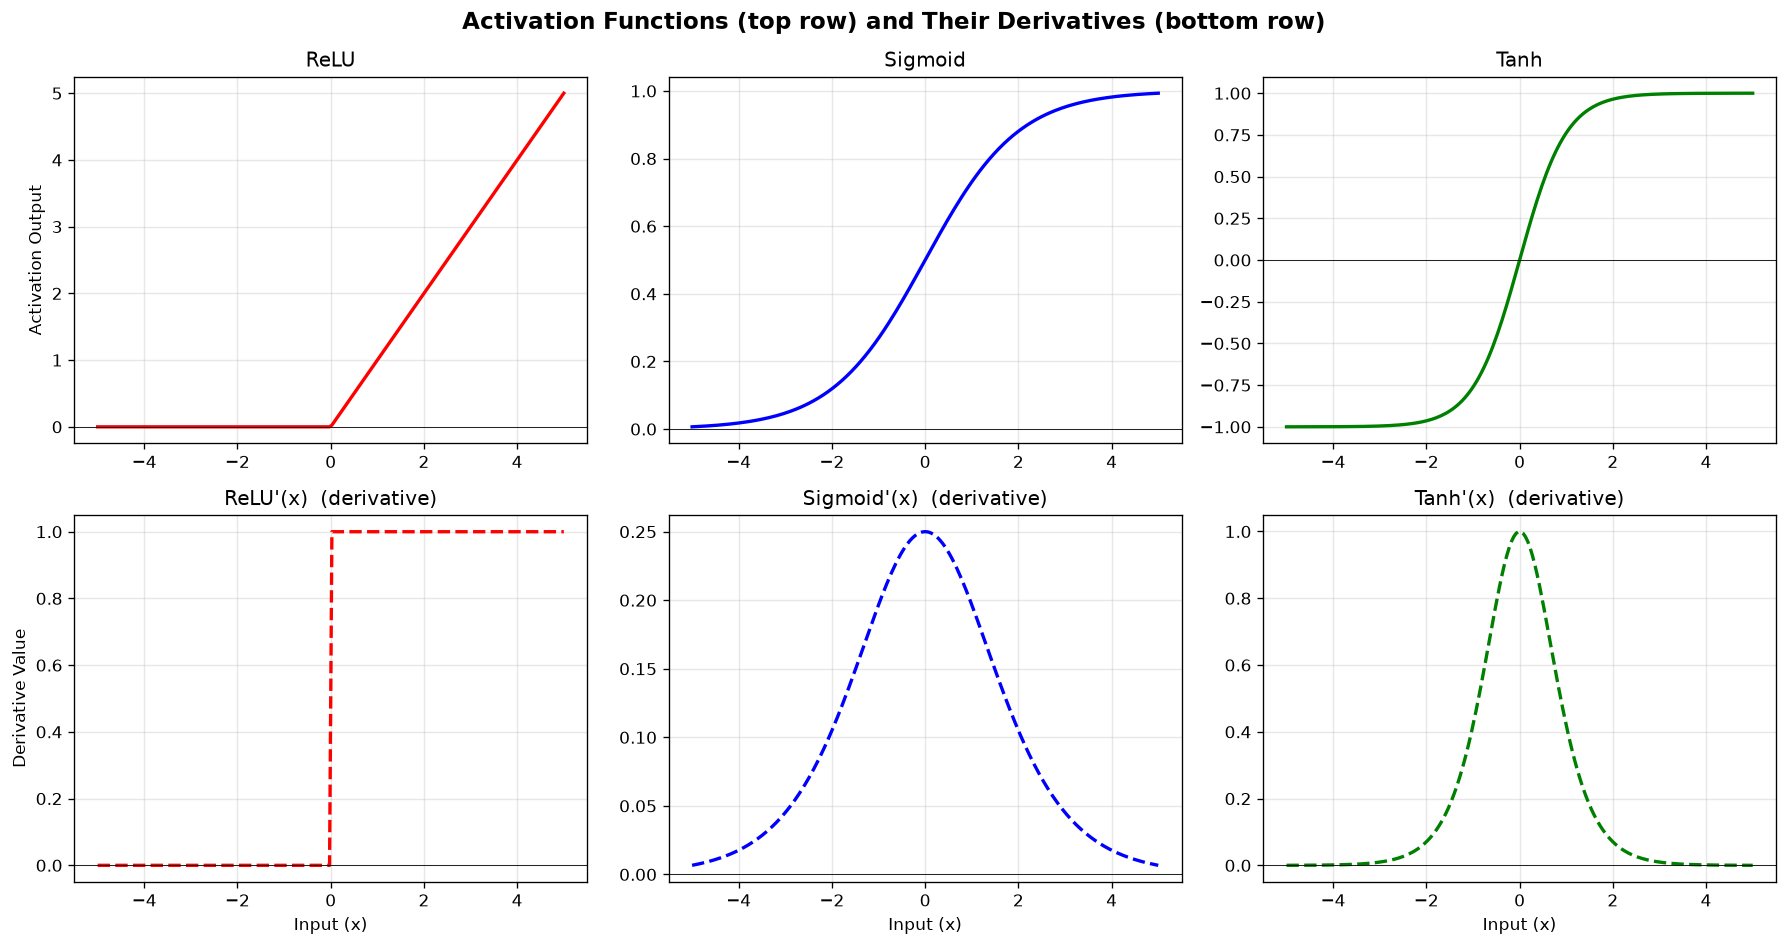

Notice the MAXIMUM value each derivative can reach:
- ReLU'(x):    max = 1.0   (either exactly 0 or exactly 1 -- never shrinks the signal)
- Sigmoid'(x): max = 0.25  (at x=0, and shrinks fast away from 0)
- Tanh'(x):    max = 1.00  (at x=0, and also shrinks away from 0)

When a network stacks many Sigmoid/Tanh layers, backprop multiplies many of these
small numbers together -- the gradient can shrink to almost nothing by the time it
reaches the earliest layers. That's the 'vanishing gradient problem', coming up next session.


In [4]:
def relu(x): return np.maximum(0, x)
def relu_derivative(x): return (x > 0).astype(float)

def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x): return np.tanh(x)
def tanh_derivative(x): return 1 - np.tanh(x) ** 2

x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Activation Functions (top row) and Their Derivatives (bottom row)', fontsize=14, fontweight='bold')

funcs = [
    ('ReLU', relu, relu_derivative, 'r'),
    ('Sigmoid', sigmoid, sigmoid_derivative, 'b'),
    ('Tanh', tanh, tanh_derivative, 'g'),
]

for col, (name, f, fprime, color) in enumerate(funcs):
    axes[0, col].plot(x, f(x), color=color, linewidth=2)
    axes[0, col].set_title(name, fontsize=12)
    axes[0, col].grid(True, alpha=0.3)
    axes[0, col].axhline(y=0, color='k', linewidth=0.5)

    axes[1, col].plot(x, fprime(x), color=color, linewidth=2, linestyle='--')
    axes[1, col].set_title(f"{name}'(x)  (derivative)", fontsize=12)
    axes[1, col].set_xlabel('Input (x)')
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].axhline(y=0, color='k', linewidth=0.5)

axes[0, 0].set_ylabel('Activation Output')
axes[1, 0].set_ylabel('Derivative Value')

plt.tight_layout()
plt.show()

print("Notice the MAXIMUM value each derivative can reach:")
print(f"- ReLU'(x):    max = 1.0   (either exactly 0 or exactly 1 -- never shrinks the signal)")
print(f"- Sigmoid'(x): max = {sigmoid_derivative(np.array([0.0]))[0]:.2f}  (at x=0, and shrinks fast away from 0)")
print(f"- Tanh'(x):    max = {tanh_derivative(np.array([0.0]))[0]:.2f}  (at x=0, and also shrinks away from 0)")
print("\nWhen a network stacks many Sigmoid/Tanh layers, backprop multiplies many of these")
print("small numbers together -- the gradient can shrink to almost nothing by the time it")
print("reaches the earliest layers. That's the 'vanishing gradient problem', coming up next session.")

---
## 5. Backpropagation Through Multiple Layers

For a 2-layer network, the backward pass moves in **reverse order**, and — this is the key efficiency trick — **reuses** the gradient computed at the output layer when computing the gradient for the hidden layer.

```
z1 = W1 . x + b1        a1 = activation(z1)
z2 = W2 . a1 + b2       a2 = activation(z2)
Loss = (a2 - target)^2
```

In [5]:
def relu(x): return np.maximum(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-x))

print("=" * 55)
print("BACKPROPAGATION THROUGH A 2-LAYER NETWORK")
print("=" * 55)

np.random.seed(42)

# One example input, one true label
x = np.array([[0.5, 0.8]])       # 1 sample, 2 features
y_true = np.array([[1.0]])       # target class = 1

# A small 2 -> 3 -> 1 network
W1 = np.array([[0.1, -0.2, 0.3], [0.4, 0.15, -0.5]])
b1 = np.zeros((1, 3))
W2 = np.array([[0.3], [-0.6], [0.2]])
b2 = np.zeros((1, 1))

# ---------------- FORWARD PASS ----------------
z1 = x.dot(W1) + b1
a1 = relu(z1)
z2 = a1.dot(W2) + b2
a2 = sigmoid(z2)
loss = np.mean((a2 - y_true) ** 2)

print("\n--- FORWARD PASS ---")
print(f"z1 (hidden pre-activation) = {z1}")
print(f"a1 (hidden, after ReLU)    = {a1}")
print(f"z2 (output pre-activation) = {z2}")
print(f"a2 (prediction, Sigmoid)   = {a2}")
print(f"Loss = {loss:.4f}")

# ---------------- BACKWARD PASS ----------------
print("\n--- BACKWARD PASS ---")

# Output layer
dloss_da2 = 2 * (a2 - y_true)
da2_dz2 = a2 * (1 - a2)                 # sigmoid derivative
dz2 = dloss_da2 * da2_dz2               # "dLoss/dz2": the output layer's error signal
dW2 = a1.T.dot(dz2)
db2 = np.sum(dz2, axis=0, keepdims=True)
print(f"dLoss/dz2 (output layer error) = {dz2}")
print(f"dLoss/dW2 = \n{dW2}")
print(f"dLoss/db2 = {db2}")

# The "blame" passed back to the hidden layer -- this REUSES dz2!
da1 = dz2.dot(W2.T)
dz1 = da1 * (z1 > 0)                    # ReLU derivative
dW1 = x.T.dot(dz1)
db1 = np.sum(dz1, axis=0, keepdims=True)
print(f"\ndLoss/da1 (blame passed back)  = {da1}")
print(f"dLoss/dz1 (hidden layer error) = {dz1}")
print(f"dLoss/dW1 = \n{dW1}")
print(f"dLoss/db1 = {db1}")

print("\ndz2 (computed once, for the OUTPUT layer) was reused to compute da1 and dz1")
print("for the HIDDEN layer -- this reuse is exactly what makes backpropagation efficient.")

BACKPROPAGATION THROUGH A 2-LAYER NETWORK

--- FORWARD PASS ---
z1 (hidden pre-activation) = [[ 0.37  0.02 -0.25]]
a1 (hidden, after ReLU)    = [[0.37 0.02 0.  ]]
z2 (output pre-activation) = [[0.099]]
a2 (prediction, Sigmoid)   = [[0.52472981]]
Loss = 0.2259

--- BACKWARD PASS ---
dLoss/dz2 (output layer error) = [[-0.23705378]]
dLoss/dW2 = 
[[-0.0877099 ]
 [-0.00474108]
 [ 0.        ]]
dLoss/db2 = [[-0.23705378]]

dLoss/da1 (blame passed back)  = [[-0.07111613  0.14223227 -0.04741076]]
dLoss/dz1 (hidden layer error) = [[-0.07111613  0.14223227 -0.        ]]
dLoss/dW1 = 
[[-0.03555807  0.07111613  0.        ]
 [-0.05689291  0.11378582  0.        ]]
dLoss/db1 = [[-0.07111613  0.14223227  0.        ]]

dz2 (computed once, for the OUTPUT layer) was reused to compute da1 and dz1
for the HIDDEN layer -- this reuse is exactly what makes backpropagation efficient.


---
## 6. Gradient Checking: Verifying Backpropagation is Correct

Backprop math is easy to get subtly wrong. A standard trick used by every deep learning practitioner is **gradient checking**: compare the analytic gradient (from backprop) against a **numerical gradient** computed by nudging a weight slightly and measuring how much the loss changes.

```
numerical_gradient ~= (Loss(w + epsilon) - Loss(w - epsilon)) / (2 * epsilon)
```

If the two match closely, we can trust our backprop implementation.

In [6]:
print("=" * 55)
print("GRADIENT CHECKING: Does our backprop math actually work?")
print("=" * 55)

def forward(x, W1, b1, W2, b2, y_true):
    z1 = x.dot(W1) + b1
    a1 = relu(z1)
    z2 = a1.dot(W2) + b2
    a2 = sigmoid(z2)
    return np.mean((a2 - y_true) ** 2)

# ---- Analytic gradient (backpropagation), reusing the values from above ----
dW1_analytic = x.T.dot((dz2.dot(W2.T)) * (z1 > 0))

# ---- Numerical gradient (finite differences) on W1[0, 0] ----
epsilon = 1e-5
W1_plus = W1.copy();  W1_plus[0, 0] += epsilon
W1_minus = W1.copy(); W1_minus[0, 0] -= epsilon

loss_plus = forward(x, W1_plus, b1, W2, b2, y_true)
loss_minus = forward(x, W1_minus, b1, W2, b2, y_true)
dW1_numerical_00 = (loss_plus - loss_minus) / (2 * epsilon)

print(f"\nChecking the gradient for W1[0, 0]:")
print(f"  Analytic  (backprop):      {dW1_analytic[0, 0]:.6f}")
print(f"  Numerical (finite diffs):  {dW1_numerical_00:.6f}")
print(f"  Difference:                {abs(dW1_analytic[0, 0] - dW1_numerical_00):.8f}")

if np.isclose(dW1_analytic[0, 0], dW1_numerical_00, atol=1e-4):
    print("\nMatch! Our backpropagation math is correct.")
else:
    print("\nMismatch! There would be a bug in the backward pass.")

GRADIENT CHECKING: Does our backprop math actually work?

Checking the gradient for W1[0, 0]:
  Analytic  (backprop):      -0.035558
  Numerical (finite diffs):  -0.035558
  Difference:                0.00000000

Match! Our backpropagation math is correct.


---
## 7. Putting It All Together: The Complete Training Loop

Now let's run the full loop from last session, but this time every step is explicitly labelled as **forward pass**, **backward pass (backpropagation)**, or **update** — the three ingredients that make a network learn.

FULL TRAINING LOOP: Forward + Backward + Update
Epoch  50/200 | Loss: 0.1547 | Accuracy: 98.00%
Epoch 100/200 | Loss: 0.0778 | Accuracy: 100.00%
Epoch 150/200 | Loss: 0.0504 | Accuracy: 100.00%
Epoch 200/200 | Loss: 0.0369 | Accuracy: 100.00%


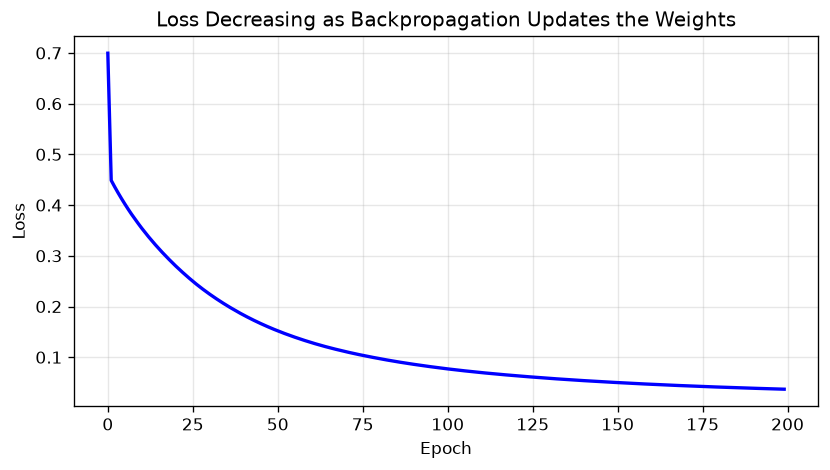


Every epoch repeats: FORWARD PASS -> BACKWARD PASS (backprop) -> UPDATE.
This is the complete training loop that lets a network learn from data!


In [7]:
print("=" * 55)
print("FULL TRAINING LOOP: Forward + Backward + Update")
print("=" * 55)

np.random.seed(42)

n_points = 50
class_0 = np.random.randn(n_points, 2) + np.array([0, 0])
class_1 = np.random.randn(n_points, 2) + np.array([3, 3])
X = np.vstack([class_0, class_1])
y = np.array([0]*n_points + [1]*n_points).reshape(-1, 1)

input_size, hidden_size, output_size = 2, 10, 1
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

learning_rate = 0.1
epochs = 200
losses = []

for epoch in range(epochs):
    # ---------------- FORWARD PASS ----------------
    z1 = X.dot(W1) + b1
    a1 = relu(z1)
    z2 = a1.dot(W2) + b2
    a2 = sigmoid(z2)

    eps = 1e-8
    loss = -np.mean(y * np.log(a2 + eps) + (1 - y) * np.log(1 - a2 + eps))
    losses.append(loss)

    # ---------------- BACKWARD PASS (backpropagation) ----------------
    dz2 = a2 - y
    dW2 = a1.T.dot(dz2) / len(X)
    db2 = np.mean(dz2, axis=0, keepdims=True)

    da1 = dz2.dot(W2.T)
    dz1 = da1 * (z1 > 0)
    dW1 = X.T.dot(dz1) / len(X)
    db1 = np.mean(dz1, axis=0, keepdims=True)

    # ---------------- UPDATE (gradient descent) ----------------
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if (epoch + 1) % 50 == 0:
        acc = np.mean((a2 > 0.5).astype(int) == y)
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss:.4f} | Accuracy: {acc:.2%}")

plt.figure(figsize=(8, 4))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Decreasing as Backpropagation Updates the Weights')
plt.grid(True, alpha=0.3)
plt.show()

print("\nEvery epoch repeats: FORWARD PASS -> BACKWARD PASS (backprop) -> UPDATE.")
print("This is the complete training loop that lets a network learn from data!")

---
## 8. Key Takeaways

### What We Learned:
1. **Backpropagation** computes the gradient of the loss with respect to *every* weight, efficiently
2. The **chain rule** is the mathematical tool that lets gradients flow backward through layers
3. Gradients computed at **later layers are reused** to compute gradients at earlier layers
4. Every activation function needs a **derivative** so backprop can flow through it
5. **Gradient checking** (comparing analytic vs. numerical gradients) verifies our backprop code is correct

### The Big Picture:
> A network learns through three repeating steps: **forward pass** (make a prediction), **backward pass / backpropagation** (figure out how each weight contributed to the error, using the chain rule), and **update** (nudge each weight with gradient descent). Backpropagation is the bridge that connects "how wrong were we?" to "how should every single weight change?" 